## Reading data

In [30]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

Data is gotten from here: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

In [2]:
df = pd.read_csv('heart.csv')
print( df.shape )

(918, 12)


In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## Cleaning data

In [4]:
#let's look at the datatypes for each column
for x in df.columns:
  print( str( type( df[x].iloc[0] ) ) + ": " + x )

<class 'numpy.int64'>: Age
<class 'str'>: Sex
<class 'str'>: ChestPainType
<class 'numpy.int64'>: RestingBP
<class 'numpy.int64'>: Cholesterol
<class 'numpy.int64'>: FastingBS
<class 'str'>: RestingECG
<class 'numpy.int64'>: MaxHR
<class 'str'>: ExerciseAngina
<class 'numpy.float64'>: Oldpeak
<class 'str'>: ST_Slope
<class 'numpy.int64'>: HeartDisease


In [5]:
#non-null values in each column
df.count()

Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64

In [6]:
for x in df.columns:
  print( df[x].value_counts() )

Age
54    51
58    42
55    41
56    38
57    38
52    36
51    35
59    35
62    35
53    33
60    32
48    31
61    31
63    30
50    25
43    24
41    24
46    24
64    22
49    21
65    21
44    19
47    19
45    18
42    18
38    16
39    15
67    15
40    13
66    13
69    13
37    11
35    11
68    10
34     7
74     7
70     7
36     6
32     5
71     5
72     4
29     3
75     3
31     2
33     2
77     2
76     2
28     1
30     1
73     1
Name: count, dtype: int64
Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64
Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64
FastingBS
0    704
1    214
Name: count, dtype:

In [7]:
#Gonna have to change this manually or find a way to do it without explicitly writing column names
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='str').columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

## Models

Splitting data into test and train

In [8]:
from sklearn.model_selection import train_test_split


X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease']


X_train, X_test, y_train, y_test = train_test_split(
  X,y , random_state=42,test_size=0.2, shuffle=True)

In [9]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(X_train)
X_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

KNN UNSCALED

In [10]:
from sklearn.neighbors import KNeighborsClassifier

K = []
training = []
test = []
scores_unscaled = {}

for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_train, y_train)

    training_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores_unscaled[k] = [training_score, test_score]

best_k_unscaled = 0
best_test_score_unscaled = 0
best_gap_unscaled = float('inf')

for k in scores_unscaled:
    test_score = scores_unscaled[k][1]
    gap = scores_unscaled[k][0] - scores_unscaled[k][1]
    if test_score > best_test_score_unscaled or (test_score == best_test_score_unscaled and gap < best_gap_unscaled):
        best_test_score_unscaled = test_score
        best_gap_unscaled = gap
        best_k_unscaled = k

print(f'Best K (unscaled): {best_k_unscaled}')
print(f'Train: {scores_unscaled[best_k_unscaled][0]:.3f}')
print(f'Test: {scores_unscaled[best_k_unscaled][1]:.3f}')

worse_knn = KNeighborsClassifier(n_neighbors=best_k_unscaled)
worse_knn.fit(X_train, y_train)

Best K (unscaled): 5
Train: 0.793
Test: 0.701


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
for keys, values in scores_unscaled.items():
    print(keys, ':', values)

2 : [0.8351498637602179, 0.5978260869565217]
3 : [0.8201634877384196, 0.6521739130434783]
4 : [0.7970027247956403, 0.6793478260869565]
5 : [0.7929155313351499, 0.7010869565217391]
6 : [0.776566757493188, 0.6630434782608695]
7 : [0.7861035422343324, 0.6630434782608695]
8 : [0.7861035422343324, 0.6413043478260869]
9 : [0.782016348773842, 0.6630434782608695]
10 : [0.771117166212534, 0.6413043478260869]
11 : [0.7697547683923706, 0.6521739130434783]
12 : [0.7683923705722071, 0.6467391304347826]
13 : [0.7588555858310627, 0.6739130434782609]
14 : [0.7493188010899182, 0.6630434782608695]
15 : [0.7465940054495913, 0.6630434782608695]
16 : [0.7397820163487738, 0.6358695652173914]
17 : [0.7465940054495913, 0.6630434782608695]
18 : [0.7370572207084468, 0.6467391304347826]
19 : [0.7452316076294278, 0.6630434782608695]
20 : [0.7329700272479565, 0.6521739130434783]


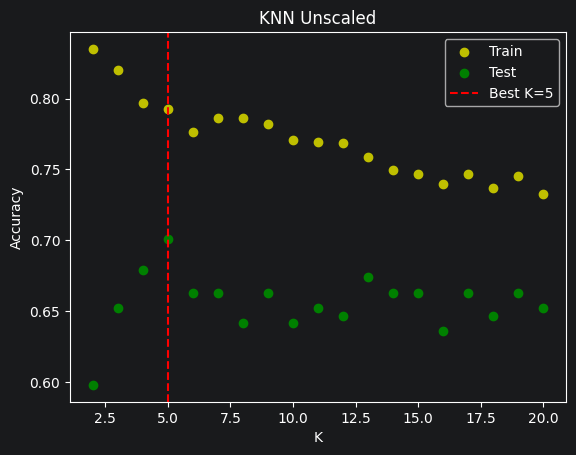

In [12]:
plt.scatter(K, training, color='y', label='Train')
plt.scatter(K, test, color='g', label='Test')
plt.axvline(best_k_unscaled, linestyle='--', color='r', label=f'Best K={best_k_unscaled}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Unscaled')
plt.legend()
plt.show()

KNN SCALED

In [13]:
# Using X_scaled because I think that will be better
K = []
training = []
test = []
scores_scaled = {}

for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_scaled, y_train)

    training_score = clf.score(X_scaled, y_train)
    test_score = clf.score(X_test_scaled, y_test)
    K.append(k)
    training.append(training_score)
    test.append(test_score)
    scores_scaled[k] = [training_score, test_score]

best_k_scaled = 0
best_test_score_scaled = 0
best_gap_scaled = float('inf')

for k in scores_scaled:
    test_score = scores_scaled[k][1]
    gap = scores_scaled[k][0] - scores_scaled[k][1]
    if test_score > best_test_score_scaled or (test_score == best_test_score_scaled and gap < best_gap_scaled):
        best_test_score_scaled = test_score
        best_gap_scaled = gap
        best_k_scaled = k

print(f'Best K (scaled): {best_k_scaled}')
print(f'Train: {scores_scaled[best_k_scaled][0]:.3f}')
print(f'Test: {scores_scaled[best_k_scaled][1]:.3f}')

# This is the best KNN because it is scaled. details are shown before
best_knn = KNeighborsClassifier(n_neighbors=best_k_scaled)
best_knn.fit(X_scaled, y_train)

Best K (scaled): 7
Train: 0.880
Test: 0.848


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
for keys, values in scores_scaled.items():
    print(keys, ':', values)

2 : [0.9073569482288828, 0.782608695652174]
3 : [0.9059945504087193, 0.8315217391304348]
4 : [0.8896457765667575, 0.8152173913043478]
5 : [0.8937329700272479, 0.8478260869565217]
6 : [0.888283378746594, 0.8369565217391305]
7 : [0.8801089918256131, 0.8478260869565217]
8 : [0.8801089918256131, 0.8260869565217391]
9 : [0.8760217983651226, 0.8315217391304348]
10 : [0.8664850136239782, 0.8260869565217391]
11 : [0.8760217983651226, 0.842391304347826]
12 : [0.8705722070844687, 0.8315217391304348]
13 : [0.8719346049046321, 0.8315217391304348]
14 : [0.8637602179836512, 0.842391304347826]
15 : [0.8705722070844687, 0.842391304347826]
16 : [0.8637602179836512, 0.8315217391304348]
17 : [0.8678474114441417, 0.8260869565217391]
18 : [0.8610354223433242, 0.842391304347826]
19 : [0.8596730245231607, 0.842391304347826]
20 : [0.8678474114441417, 0.8369565217391305]


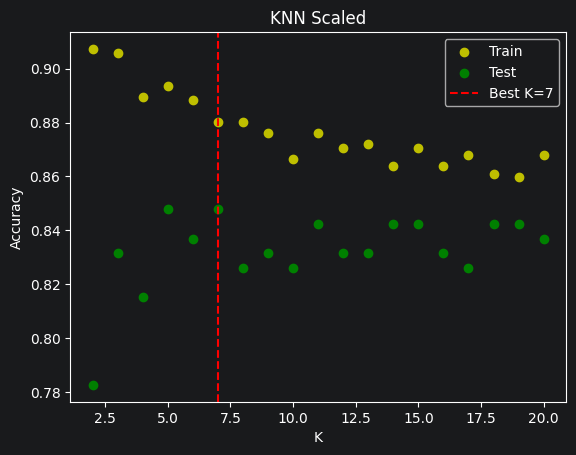

In [15]:
plt.scatter(K, training, color='y', label='Train')
plt.scatter(K, test, color='g', label='Test')
plt.axvline(best_k_scaled, linestyle='--', color='r', label=f'Best K={best_k_scaled}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Scaled')
plt.legend()
plt.show()

DecisionTree

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [17]:
# Decision tree without tuning
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)


training_score = dt_default.score(X_train, y_train)
test_score = dt_default.score(X_test, y_test)

print( f'Train: {training_score}' )
print( f'Test: {test_score}' )

Train: 1.0
Test: 0.782608695652174


[Text(0.5475833333333333, 0.96875, 'x[10] <= 1.5\ngini = 0.496\nsamples = 734\nvalue = [333, 401]'),
 Text(0.2885, 0.90625, 'x[2] <= 0.5\ngini = 0.305\nsamples = 427\nvalue = [80, 347]'),
 Text(0.41804166666666664, 0.9375, 'True  '),
 Text(0.129, 0.84375, 'x[1] <= 0.5\ngini = 0.177\nsamples = 296\nvalue = [29, 267]'),
 Text(0.07466666666666667, 0.78125, 'x[9] <= 1.3\ngini = 0.387\nsamples = 42\nvalue = [11, 31]'),
 Text(0.05333333333333334, 0.71875, 'x[0] <= 62.5\ngini = 0.48\nsamples = 25\nvalue = [10, 15]'),
 Text(0.042666666666666665, 0.65625, 'x[6] <= 0.5\ngini = 0.494\nsamples = 18\nvalue = [10, 8]'),
 Text(0.021333333333333333, 0.59375, 'x[3] <= 142.5\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.010666666666666666, 0.53125, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.032, 0.53125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.064, 0.59375, 'x[7] <= 136.5\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.05333333333333334, 0.53125, 'x[4] <= 98.5\ngini =

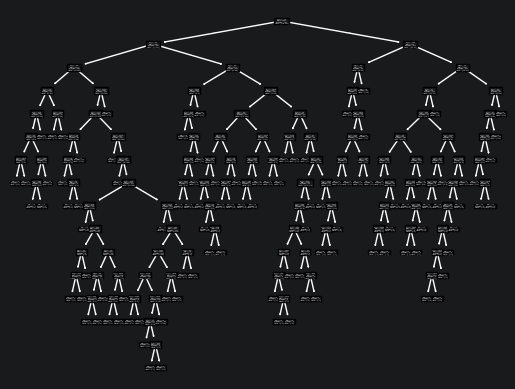

In [18]:
tree.plot_tree(dt_default)

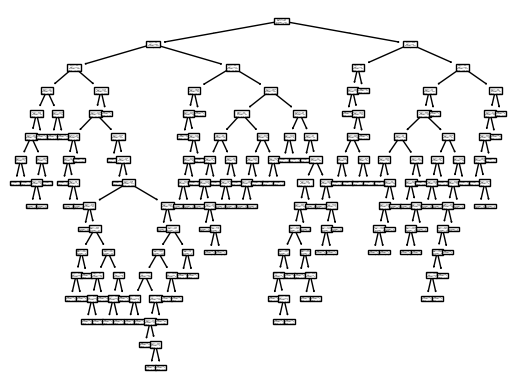

In [19]:
from sklearn.metrics import accuracy_score
y_pred = dt_default.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.782608695652174


In [20]:
from sklearn.model_selection import GridSearchCV

#Hyperparameter to fine tune
param_grids = {
    'shallow': {
        'max_depth': range(2, 8),
        'min_samples_leaf': range(5, 25, 2),
        'min_samples_split': range(5, 25, 2),
        'criterion': ['entropy', 'gini'],
        'class_weight': [None, 'balanced']
    },
    'deep': {
        'max_depth': range(5, 15),
        'min_samples_leaf': range(1, 10),
        'min_samples_split': range(2, 10),
        'criterion': ['entropy', 'gini'],
        'class_weight': [None, 'balanced']
    },
    'wide': {
        'max_depth': range(2, 15),
        'min_samples_leaf': range(1, 30, 3),
        'min_samples_split': range(2, 30, 3),
        'criterion': ['entropy', 'gini'],
        'max_features': [None, 'sqrt', 'log2']
    }
}

best_dt = None
best_dt_name = ''
best_dt_score = 0

for name, params in param_grids.items():
    gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, verbose=True)
    gs.fit(X_train, y_train)
    train_score = gs.best_estimator_.score(X_train, y_train)
    test_score = gs.best_estimator_.score(X_test, y_test)
    print(f'{name} - train: {train_score:.3f} | test: {test_score:.3f}')
    print(f'  best params: {gs.best_params_}')
    if test_score > best_dt_score:
        best_dt_score = test_score
        best_dt = gs.best_estimator_
        best_dt_name = name

print(f'\nbest grid: {best_dt_name} ({best_dt_score:.3f})')

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
shallow - train: 0.869 | test: 0.875
  best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 5}
Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
deep - train: 0.876 | test: 0.859
  best params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 8}
Fitting 5 folds for each of 7800 candidates, totalling 39000 fits
wide - train: 0.883 | test: 0.842
  best params: {'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 17}

best grid: shallow (0.875)


Naive Bayes

In [21]:
from sklearn.naive_bayes import GaussianNB

In [22]:
# GaussianNB is appropriate here because our features are numeric
gnb = GaussianNB()
gnb.fit(X_train, y_train)

training_score = gnb.score(X_train, y_train)
test_score = gnb.score(X_test, y_test)

print(f'Train: {training_score}')
print(f'Test: {test_score}')

params = {'var_smoothing': np.logspace(-12, 0, 100)}
nb_grid = GridSearchCV(GaussianNB(), params, cv=5)
nb_grid.fit(X_train, y_train)

print(f'best var_smoothing: {nb_grid.best_params_}')

best_gnb = nb_grid.best_estimator_
print(f'train: {best_gnb.score(X_train, y_train):.3f}')
print(f'test: {best_gnb.score(X_test, y_test):.3f}')

Train: 0.8637602179836512
Test: 0.842391304347826
best var_smoothing: {'var_smoothing': np.float64(5.3366992312063125e-08)}
train: 0.864
test: 0.842


In [23]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay)

Evaluation

In [24]:
# Evaluate your model and compare it to the other models (Decision Trees and KNN)
# Predictions from each model
knn_u_preds = worse_knn.predict(X_test)
knn_s_preds = best_knn.predict(X_test_scaled)
dt_preds = best_dt.predict(X_test)
nb_preds = best_gnb.predict(X_test)

models = {
    'KNN unscaled': knn_u_preds,
    'KNN scaled': knn_s_preds,
    'Decision Tree': dt_preds,
    'Naive Bayes': nb_preds
}

In [25]:
# Print all metrics
print(f"{'Model'}       {'Accuracy'} {'Precision'} {'Recall'} {'F1'}")

for name, preds in models.items():
    acc = (preds == y_test).mean()
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name}: {acc:.3f} {prec:.3f} {rec:.3f} {f1:.3f}")

Model       Accuracy Precision Recall F1
KNN unscaled: 0.701 0.771 0.692 0.729
KNN scaled: 0.848 0.899 0.832 0.864
Decision Tree: 0.875 0.896 0.888 0.892
Naive Bayes: 0.842 0.882 0.841 0.861


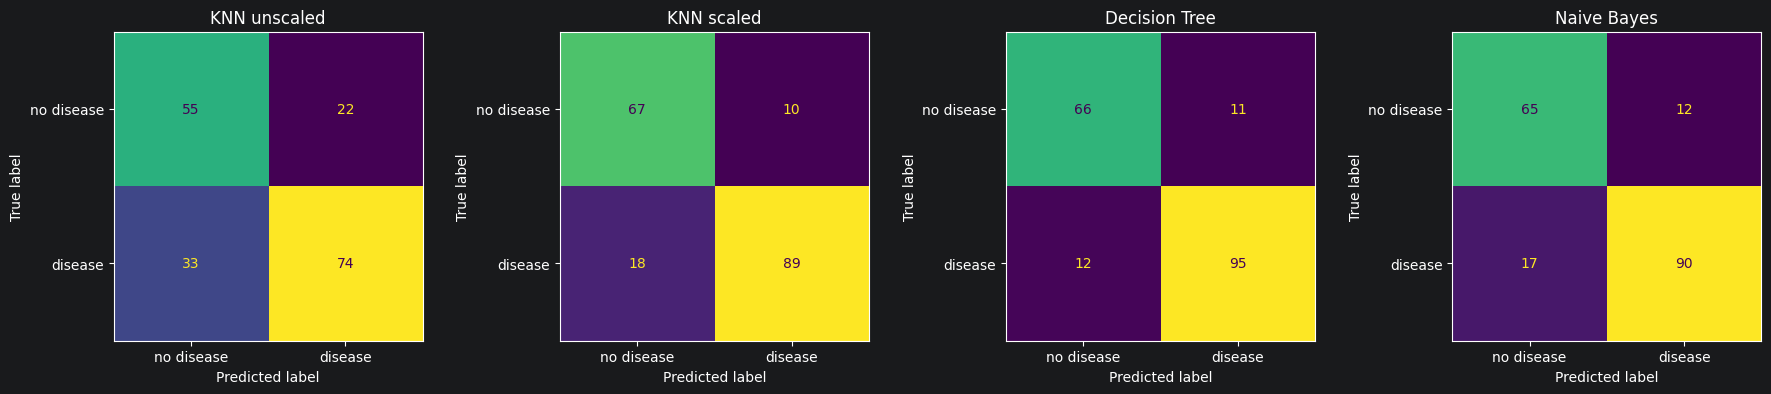

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no disease', 'disease'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

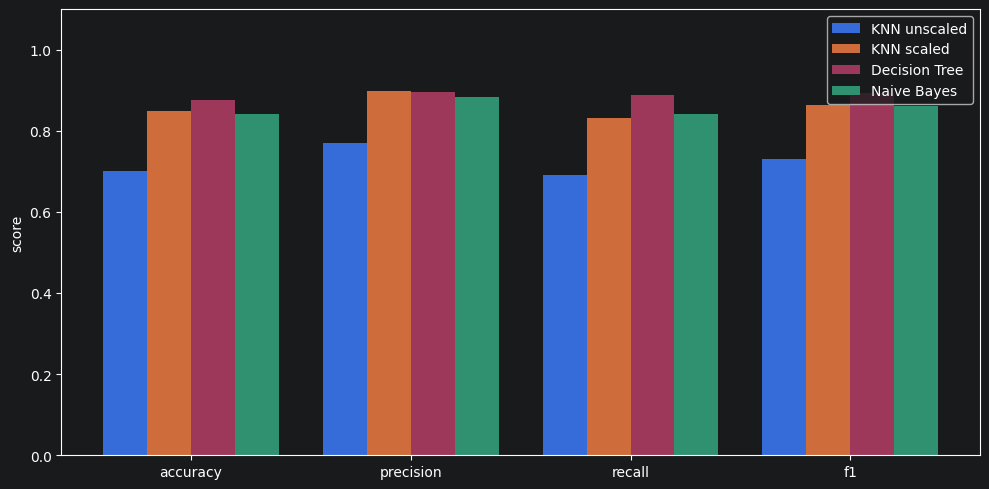

In [27]:
metric_names = ['accuracy', 'precision', 'recall', 'f1']
results = []
for name, preds in models.items():
    results.append([
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, zero_division=0),
        recall_score(y_test, preds, zero_division=0),
        f1_score(y_test, preds, zero_division=0)
    ])

results = np.array(results)
x = np.arange(len(metric_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(models.keys()):
    ax.bar(x + i * width, results[i], width, label=name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('score')
ax.legend()
plt.tight_layout()
plt.show()